In [1]:
import matplotlib.pyplot as plt
from FOX import MultiMolecule
import numpy as np
from ase.io import read
from scipy.ndimage import gaussian_filter1d

In [2]:
atoms_lr = read("./zn_charges.extxyz", index=":")[1000:]
atoms_baseline = read("./baseline/zn_300_100.000ps.xyz", index=":")[1000:]

In [3]:
traj_lr = MultiMolecule.from_ase(atoms_lr)
traj_baseline = MultiMolecule.from_ase(atoms_baseline)

rdf_lr = traj_lr.init_rdf(r_max=6, dr=0.01, periodic=["x", "y", "z"])
rdf_baseline = traj_baseline.init_rdf(r_max=6, dr=0.01, periodic=["x", "y", "z"])

(array([1.5, 2. , 2.5, 3. , 3.5, 4. ]),
 [Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0')])

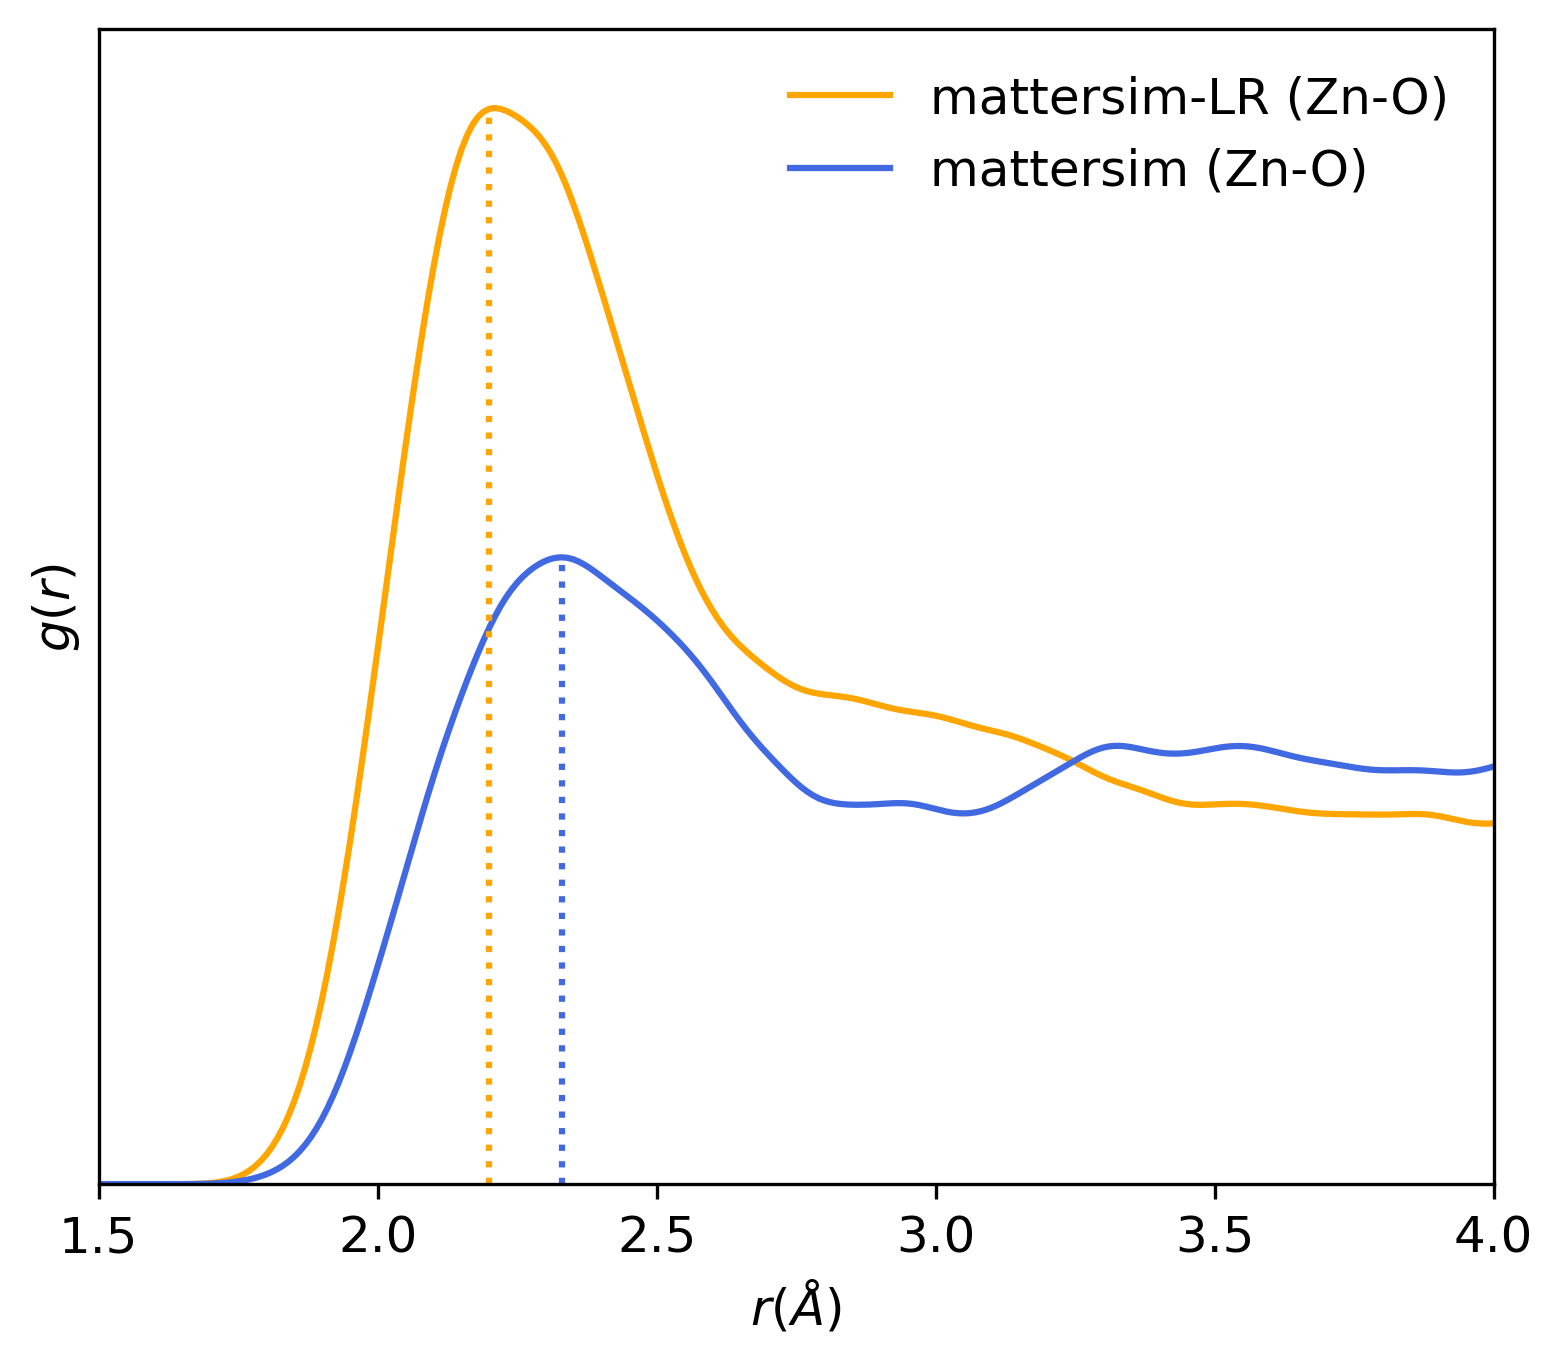

In [30]:
sigma=5

plt.figure(figsize=(6,5), dpi=300)
plt.plot(rdf_lr.index, gaussian_filter1d(rdf_lr["O Zn"], sigma=sigma), color='orange', label="mattersim-LR (Zn-O)")
# plt.plot(rdf_lr.index, gaussian_filter1d(rdf_lr["H Zn"], sigma=sigma), color='royalblue', label="mattersim-LR (Zn-H)")

plt.plot(rdf_lr.index, gaussian_filter1d(rdf_baseline["O Zn"], sigma=sigma), color='royalblue', label="mattersim (Zn-O)")
# plt.plot(rdf_lr.index, gaussian_filter1d(rdf_baseline["H Zn"], sigma=sigma), ':', color='royalblue',label="mattersim (Zn-H)")
plt.legend(frameon=False, fontsize=12)
plt.vlines(np.argmax(rdf_lr["O Zn"])*0.01, 0, max(gaussian_filter1d(rdf_lr["O Zn"], sigma=sigma)), color='orange', linestyle=':')
plt.vlines(np.argmax(rdf_baseline["O Zn"])*0.01, 0, max(gaussian_filter1d(rdf_baseline["O Zn"], sigma=sigma)), color='royalblue', linestyle=':')

plt.xlim([1.5, 4])
plt.ylim([0, max(gaussian_filter1d(rdf_lr["O Zn"], sigma=sigma))+0.2])
plt.ylabel(r"$g(r)$", fontsize=12)
plt.yticks([])
plt.xlabel(rf'$r (\AA)$', fontsize=12)
plt.xticks(fontsize=12)

In [5]:
np.argmax(rdf_lr["H Zn"])/100

2.56

In [6]:
np.argmax(rdf_baseline["O Zn"])/100

2.33

In [10]:
np.argmax(rdf_baseline["H Zn"])/100

2.66

In [7]:
np.argmax(rdf_lr["O Zn"])/100

2.2

In [8]:
cutoff_ZnO = 3.4

traj = atoms_lr

frame_coord_numbers = []   # store per-frame coordination (averaged over Zn)

for atoms in traj:
    symbols = atoms.get_chemical_symbols()

    # Indices of Zn atoms
    zn_indices = [i for i, s in enumerate(symbols) if s == "Zn"]

    # Indices of water oxygens (simplest case: all O atoms)
    # If you have other oxygens (e.g. ligands), you'll need a more selective filter.
    o_indices = [i for i, s in enumerate(symbols) if s == "O"]

    # For each Zn, count O within cutoff
    zn_coord = []
    for izn in zn_indices:
        # distances from this Zn to all O; mic=True to respect PBC
        dists = atoms.get_distances(izn, o_indices, mic=True)
        n_coord = np.sum(dists < cutoff_ZnO)
        zn_coord.append(n_coord)

    # Average over all Zn in this frame
    frame_coord_numbers.append(np.mean(zn_coord))

frame_coord_numbers = np.array(frame_coord_numbers)

# Overall average coordination number
mean_coord = np.nanmean(frame_coord_numbers)
std_coord = np.nanstd(frame_coord_numbers)

print(f"Average Zn–water coordination = {mean_coord:.3f} ± {std_coord:.3f}")
print(f"(Based on {len(frame_coord_numbers)} frames)")


Average Zn–water coordination = 5.777 ± 0.635
(Based on 4001 frames)


In [9]:
cutoff_ZnO = 3.4

traj = atoms_baseline

frame_coord_numbers = []   # store per-frame coordination (averaged over Zn)

for atoms in traj:
    symbols = atoms.get_chemical_symbols()

    # Indices of Zn atoms
    zn_indices = [i for i, s in enumerate(symbols) if s == "Zn"]

    # Indices of water oxygens (simplest case: all O atoms)
    # If you have other oxygens (e.g. ligands), you'll need a more selective filter.
    o_indices = [i for i, s in enumerate(symbols) if s == "O"]

    # For each Zn, count O within cutoff
    zn_coord = []
    for izn in zn_indices:
        # distances from this Zn to all O; mic=True to respect PBC
        dists = atoms.get_distances(izn, o_indices, mic=True)
        n_coord = np.sum(dists < cutoff_ZnO)
        zn_coord.append(n_coord)

    # Average over all Zn in this frame
    frame_coord_numbers.append(np.mean(zn_coord))

frame_coord_numbers = np.array(frame_coord_numbers)

# Overall average coordination number
mean_coord = np.nanmean(frame_coord_numbers)
std_coord = np.nanstd(frame_coord_numbers)

print(f"Average Zn–water coordination = {mean_coord:.3f} ± {std_coord:.3f}")
print(f"(Based on {len(frame_coord_numbers)} frames)")


Average Zn–water coordination = 4.347 ± 0.603
(Based on 4001 frames)
